# Loading, plotting, and fitting CTR measurements

This tutorial uses the preferred metadata-aware CTR API. A `CTR` stores one
rod; `MeasurementReduction` states whether its values are structure factors or
absolute reflectivity; and `PolarizationReduction` records the incident and
outgoing polarization treatment.

The examples are reproducible simulations, but data generation is deliberately
kept out of the notebook. The standalone
`examples/CTR/generate_ctr_workflow_data.py` script writes the two tracked,
ANAROD-like orGUI CTR files used below. The notebook starts where an analysis
normally starts: loading reduced data in one line.


In [1]:
%matplotlib inline
from pathlib import Path
from tempfile import TemporaryDirectory
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares
from silx.io.dictdump import dicttonx, nxtodict

from orgui.datautils.xrayutils import CTRcalc, CTRopt, CTRuc, unitcells
from orgui.datautils.xrayutils.CTRdistributions import PoissonProfile
from orgui.datautils.xrayutils.CTRplotutil import (
    CTRCollection,
    CTRFigure,
    CTRScanGeometry,
    MeasurementReduction,
    PolarizationReduction,
    ctrfigure,
)


def _find_repository_root():
    '''Return the checkout containing this documentation notebook.'''
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "orgui" / "datautils").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from an orGUI checkout.")


repository_root = _find_repository_root()
data_directory = repository_root / "doc/source/_static"


## Preferred API: load a Pt(100) structure-factor rod

The first file contains 600 points on the Pt(100) $(2\ 0\ L)$ rod from
$L=0.02$ through $L=6$, including the first three non-zero Bragg peaks. Its
schema-2 comment header identifies the stored quantity and polarization
provenance; the numerical columns remain a compact whitespace table:
`H K L F_HKL errorF polarization_factor`.

The generator expands the last Pt(100) interplanar spacing by 2%, increases the
shared surface-atom Debye--Waller value by 40%, samples Poisson photon counts,
and finally multiplies both $F$ and $\sigma_F$ by 3.7 to emulate data on an
unknown experimental scale.


In [2]:
pt_data_path = data_directory / "ctr_pt100_20l.ctr"
pt_measurements = CTRCollection.fromCTRFile(pt_data_path)

pt_rod = pt_measurements[0]
pt_polarization = pt_rod.reduction.polarization
(
    pt_rod.hk,
    pt_rod.l.size,
    (pt_rod.l.min(), pt_rod.l.max()),
    pt_rod.reduction.quantity,
    pt_polarization.s_fraction,
    pt_polarization.outgoing,
    pt_polarization.polarization_factor.shape,
)


((np.float64(2.0), np.float64(0.0)),
 600,
 (np.float64(0.02), np.float64(6.0)),
 'structure_factor',
 1.0,
 's',
 (600,))

### Plot with `CTRFigure`

`ctrfigure()` returns a Matplotlib figure registered as `CTRFigure`. A
collection carries reusable plot settings, and the y-axis label follows the
stored measurement quantity.


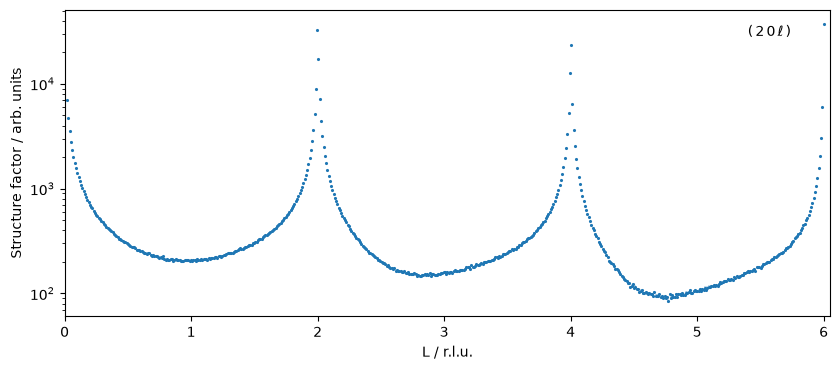

In [3]:
pt_measurements.setPlotSettings(
    linestyle="", marker=".", markersize=2.5, elinewidth=0.35,
    color="tab:blue", label="simulated measurement", xlim=(0.0, 6.05),
)

pt_figure = ctrfigure(figsize=(8.5, 3.8))
assert isinstance(pt_figure, CTRFigure)
pt_figure.addCollection(pt_measurements)
pt_figure.generateCTRplot(
    cols=1, rodlabel="topright", rodLabelL=True, share_axes=False
)
plt.show()


## Fit the Pt surface expansion and Debye--Waller factor

The fit model starts at the bulk termination: zero surface expansion and the
bulk Debye--Waller value, 0.4353. One shared parameter moves both atoms in the
outer plane along fractional $z$; a second shared parameter changes both their
in-plane and out-of-plane Debye--Waller values.

The generated $F$ values have an arbitrary scale. `scale_policy={"F":
"scaled"}` therefore determines one positive analytical scale at each model
evaluation while the numerical optimizer varies only the two structural
parameters.


In [4]:
PT_BULK_DW = 0.4353


def _build_pt100_fit_model():
    '''Return a bulk-terminated Pt(100) model with two active parameters.'''
    bulk = unitcells.unitcell("Pt100")
    surface = CTRuc.UnitCell(
        bulk.a, np.rad2deg(bulk.alpha), name="Pt_surface"
    )
    surface.addAtom("Pt", [0.0, 0.0, 0.0], PT_BULK_DW, PT_BULK_DW, 1.0)
    surface.addAtom("Pt", [0.5, 0.5, 0.0], PT_BULK_DW, PT_BULK_DW, 1.0)

    crystal = CTRcalc.SXRDCrystal(bulk, surface)
    crystal.setEnergy(20_000.0)  # eV
    surface.addFitParameter(
        ([0, 1], ["z", "z"]),
        limits=(-0.03, 0.04),
        name="surface_expansion",
    )
    surface.addFitParameter(
        ([0, 0, 1, 1], ["iDW", "oDW", "iDW", "oDW"]),
        limits=(0.2, 0.9),
        name="surface_DW",
    )
    return crystal


pt_model = _build_pt100_fit_model()


In [5]:
pt_model

E = 20.00000 keV
# UnitCell Pt_surface
0000 occupancy = 1.00000
return
Coherent 1.00000   1.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000
3.9242 3.9242 3.9242 90.0000 90.0000 90.0000
Name        x/frac      y/frac      z/frac       iDW       oDW     occup  layerIdx
00  Pt         0.00000     0.00000     0.00000    0.4353    0.4353    1.0000         0
01  Pt         0.50000     0.50000     0.00000    0.4353    0.4353    1.0000         0
layerpos: 0.0 = 0.0
layer_behaviour: ignore

# UnitCell bulk
return
Coherent 1.00000   1.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000 1.00000 0.00000 0.00000 0.00000
3.9242 3.9242 3.9242 90.0000 90.0000 90.0000
Name        x/frac      y/frac      z/frac       iDW       oDW     occup  layerIdx
00  Pt         0.00000     0.00000    -1.00000    0.4353    0.4353    1.0000         0
01  Pt         0.50000     0.50000    -1.00000    0.4353    0.4353    1.0000         0
02  Pt         0.50000     

In [6]:
pt_optimizer = CTRopt.CTROptimizer(
    pt_model, pt_measurements, scale_policy={"F": "scaled"}
)
pt_optimizer.prepareFit()
pt_start = pt_optimizer.get_parameters().copy()

started = perf_counter()
pt_result = least_squares(
    pt_optimizer.weighted_residues,
    pt_start,
    bounds=pt_optimizer.get_bounds(),
    max_nfev=40,
)
pt_fit_seconds = perf_counter() - started
pt_optimizer.flat_prediction(pt_result.x)

{
    "parameter names": pt_optimizer.fitparnames,
    "start": pt_start,
    "fit": pt_result.x,
    "surface expansion (%)": 100.0 * pt_result.x[0] / 0.5,
    "surface DW increase (%)": 100.0 * (pt_result.x[1] / PT_BULK_DW - 1.0),
    "fit time (s)": pt_fit_seconds,
}


{'parameter names': [np.str_('surface_expansion'), np.str_('surface_DW')],
 'start': array([0.    , 0.4353]),
 'fit': array([0.00996334, 0.61178586]),
 'surface expansion (%)': np.float64(1.9926689496467116),
 'surface DW increase (%)': np.float64(40.543500110233865),
 'fit time (s)': 0.017845199996372685}

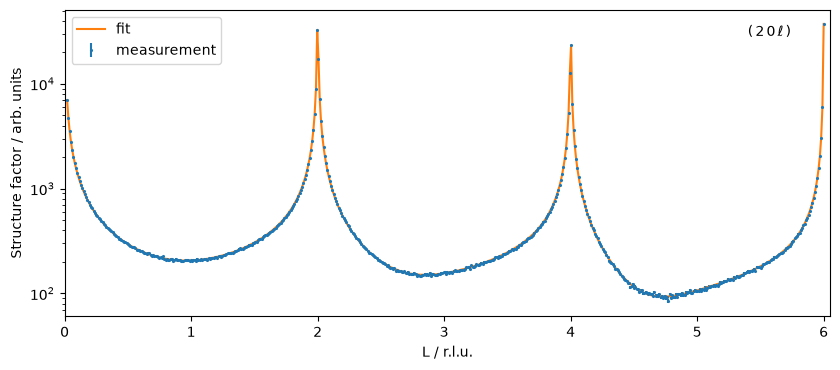

In [7]:
pt_measurements.setPlotSettings(
    linestyle="", marker=".", markersize=2.5, color="tab:blue",
    label="measurement", xlim=(0.0, 6.05),
)
pt_optimizer.calculated_CTRs.setPlotSettings(
    linestyle="-", marker="", color="tab:orange", label="fit",
    xlim=(0.0, 6.05),
)
pt_fit_figure = ctrfigure(figsize=(8.5, 3.8))
pt_fit_figure.addCollection(pt_measurements)
pt_fit_figure.addCollection(pt_optimizer.calculated_CTRs)
pt_fit_figure.generateCTRplot(
    cols=1, rodlabel="topright", rodLabelL=True, share_axes=False
)
pt_fit_figure.axes[0].legend()
plt.show()


## Absolute RuO2/TiO2 reflectivity

The second generated file contains the specular $(0\ 0\ L)$ rod over
$0.015 \leq L \leq 0.595$. Its values are dimensionless absolute
reflectivity, not structure-factor amplitudes. The RuO2 film terminates in a
fully Poissonian etched surface (`alpha=1`) with true signed mean change
`W=-6` structural layers.

The file stores `H K L R errorR`. It intentionally has no
`polarization_factor`: corrected absolute $R$ must not be divided by a
conventional intensity correction. The equal-angle scan rule is measurement
geometry rather than reduction metadata, so it is supplied to the loader.


In [8]:
reflectivity_path = data_directory / "ctr_ruo2_tio2_00l.ctr"
reflectivity_measurements = CTRCollection.fromCTRFile(
    reflectivity_path, scan_geometry=CTRScanGeometry("eq")
)

reflectivity_rod = reflectivity_measurements[0]
(
    reflectivity_rod.hk,
    reflectivity_rod.l.size,
    (reflectivity_rod.l.min(), reflectivity_rod.l.max()),
    reflectivity_rod.reduction,
    reflectivity_rod.scan_geometry,
)


((np.float64(0.0), np.float64(0.0)),
 240,
 (np.float64(0.015), np.float64(0.595)),
 MeasurementReduction(quantity='reflectivity', polarization=PolarizationReduction(s_fraction=1.0, outgoing='s', polarization_factor=None)),
 CTRScanGeometry(fixed='eq', angle=None, mirrorx=False))

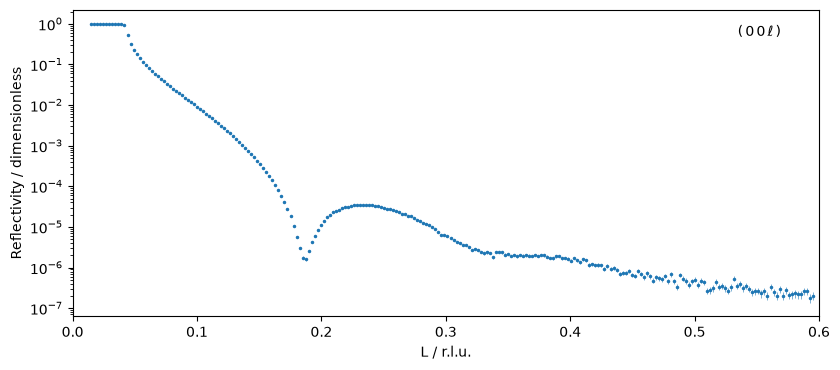

In [9]:
reflectivity_measurements.setPlotSettings(
    linestyle="", marker=".", markersize=3.0, elinewidth=0.4,
    color="tab:blue", label="absolute reflectivity", xlim=(0.0, 0.6),
)
reflectivity_figure = ctrfigure(figsize=(8.5, 3.8))
reflectivity_figure.addCollection(reflectivity_measurements)
reflectivity_figure.generateCTRplot(
    cols=1, rodlabel="topright", rodLabelL=True, share_axes=False
)
plt.show()


### Fit Poisson roughness on the absolute scale

The bundled RuO2/TiO2 model supplies the substrate, interface, film, and
termination bank. We deliberately move the fit start from the generated
`W=-6` to `W=-1`, enable only `W`, and activate live DWBA prediction.

`scale_policy={"R": "fixed"}` is essential: the prediction remains on the
absolute reflectivity scale, so roughness cannot be hidden by an analytical
normalization.


In [10]:
reflectivity_model_path = (
    repository_root / "examples/CTR/RuO2_TiO2_Poisson_etching.xtal"
)
reflectivity_model = CTRcalc.SXRDCrystal.fromFile(reflectivity_model_path)
surface = reflectivity_model["RuO2surface"]
original_profile = surface.profile
surface.basis[0] = -1.0
surface.basis_0[:] = surface.basis
surface.profile = PoissonProfile(
    mean_change=-1.0,
    alpha=original_profile.alpha,
    offset=original_profile.offset,
    tail_probability=original_profile.tail_probability,
)
surface.addFitParameter(
    "W", limits=(-9.0, -0.2), name="poisson_mean_change"
)

reflectivity_optimizer = CTRopt.CTROptimizer(
    reflectivity_model,
    reflectivity_measurements,
    scale_policy={"R": "fixed"},
)
reflectivity_optimizer.set_dwba()
reflectivity_optimizer.prepareFit()
reflectivity_start = reflectivity_optimizer.get_parameters().copy()

started = perf_counter()
reflectivity_result = least_squares(
    reflectivity_optimizer.weighted_residues,
    reflectivity_start,
    bounds=reflectivity_optimizer.get_bounds(),
    max_nfev=25,
)
reflectivity_fit_seconds = perf_counter() - started
reflectivity_optimizer.flat_prediction(reflectivity_result.x)

{
    "parameter names": reflectivity_optimizer.fitparnames,
    "start W (layers)": reflectivity_start[0],
    "fit W (layers)": reflectivity_result.x[0],
    "absolute-R scale policy": reflectivity_optimizer.get_scale_policy((0, 0)),
    "fit time (s)": reflectivity_fit_seconds,
}


{'parameter names': [np.str_('poisson_mean_change')],
 'start W (layers)': np.float64(-1.0),
 'fit W (layers)': np.float64(-6.000433335112308),
 'absolute-R scale policy': 'fixed',
 'fit time (s)': 2.3360414000053424}

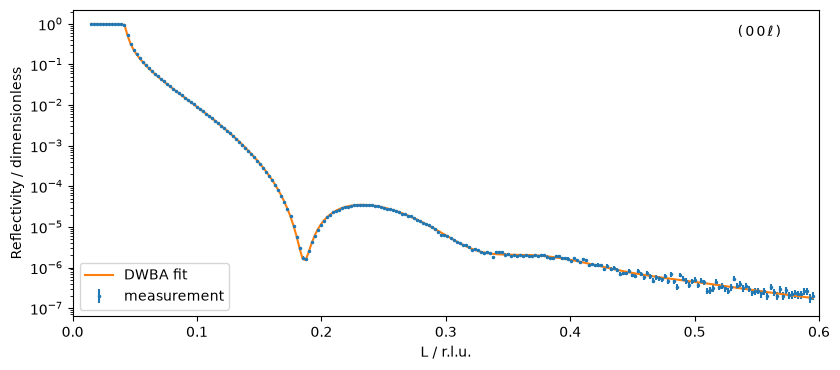

In [11]:
reflectivity_measurements.setPlotSettings(
    linestyle="", marker=".", markersize=3.0, color="tab:blue",
    label="measurement", xlim=(0.0, 0.6),
)
reflectivity_optimizer.calculated_CTRs.setPlotSettings(
    linestyle="-", marker="", color="tab:orange", label="DWBA fit",
    xlim=(0.0, 0.6),
)
reflectivity_fit_figure = ctrfigure(figsize=(8.5, 3.8))
reflectivity_fit_figure.addCollection(reflectivity_measurements)
reflectivity_fit_figure.addCollection(reflectivity_optimizer.calculated_CTRs)
reflectivity_fit_figure.generateCTRplot(
    cols=1, rodlabel="topright", rodLabelL=True, share_axes=False
)
reflectivity_fit_figure.axes[0].legend()
plt.show()


## Persist and reload complete measurements

Schema-2 NeXus persistence retains each rod's quantity, polarization metadata,
pointwise conventional factor, uncertainties, and optional scan geometry. The
temporary mixed-$F$/$R$ round trip below is self-contained.


In [12]:
all_measurements = CTRCollection(
    [*pt_measurements, *reflectivity_measurements], name="CTR workflow"
)
with TemporaryDirectory() as temporary_directory:
    nexus_path = Path(temporary_directory) / "reduced_ctrs.nxs"
    dicttonx({"entry": all_measurements.toNXdict()}, str(nexus_path))
    payload = nxtodict(str(nexus_path))["entry"]
    loaded_measurements = CTRCollection.fromNXdict(payload)

[
    (rod.hk, rod.reduction.quantity, rod.scan_geometry)
    for rod in loaded_measurements
]


[((np.float64(0.0), np.float64(0.0)),
  'reflectivity',
  CTRScanGeometry(fixed='eq', angle=None, mirrorx=False)),
 ((np.float64(2.0), np.float64(0.0)), 'structure_factor', None)]

## Make old ANAROD data metadata-compatible

ANAROD text files carry numerical columns but no measurement-reduction
metadata. `CTRCollection.fromANAROD` therefore defaults to structure-factor
data with unknown polarization provenance. That remains suitable for legacy
kinematical work, but it is insufficient for a polarization-aware calculation.

If—and only if—the reduction provenance is independently known, construct
`MeasurementReduction` and `PolarizationReduction` explicitly while importing.
The tracked fixture below contains `H K L F_HKL phi mode`, so `RODexport=True`
interprets column five as phase. For the common `H K L F_HKL errorF mode`
layout, retain the default `RODexport=False`.


In [13]:
anarod_path = (
    repository_root
    / "orgui/datautils/xrayutils/test/testdata/CTRs_reference.dat"
)

legacy_default = CTRCollection.fromANAROD(anarod_path, RODexport=True)
legacy_default[0].reduction


MeasurementReduction(quantity='structure_factor', polarization=None)

In [14]:
legacy_reduction = MeasurementReduction(
    quantity="structure_factor",
    polarization=PolarizationReduction(
        s_fraction=1.0,
        outgoing="unanalysed",
        polarization_factor=None,
    ),
)

legacy_compatible = CTRCollection.fromANAROD(
    anarod_path,
    RODexport=True,
    reduction=legacy_reduction,
    name="legacy ANAROD with explicit provenance",
)
legacy_compatible[0].reduction


MeasurementReduction(quantity='structure_factor', polarization=PolarizationReduction(s_fraction=1.0, outgoing='unanalysed', polarization_factor=None))

### Legacy migration checklist

1. Confirm whether column four is $F$, corrected $R$, or intensity requiring a
   further conversion.
2. Confirm whether column five is `errorF` or phase and select `RODexport`
   accordingly.
3. Recover `s_fraction`, `outgoing`, and any row-aligned conventional factor
   $P$ from trustworthy beamline or reduction records.
4. Import with `reduction=...`; if provenance is unavailable, retain
   `MeasurementReduction()` rather than guessing.
5. Write schema-2 NeXus for subsequent metadata-preserving loads.
